# 10.5 Implementing K-Means Clustering using Python

In [1]:
# CH.SC.U4CSE24119 Kavin JS

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

## Create Amazon Users Dataset

The original Amazon dataset link is no longer available. We synthesize a reproducible 200-row dataset matching the book's printed table columns: Cus_ID, Sex, Age, Income, Rating.

In [2]:
rng = np.random.default_rng(42)
n = 200
cus_ids = list(range(301219, 301219 + n))
sex = rng.choice(['M', 'F'], n)
age = rng.integers(20, 60, n)
# Income follows a pattern similar to the book: roughly 300k to 2.8M
income = rng.integers(250000, 2800000, n)
rating = rng.integers(0, 100, n)

data = pd.DataFrame({
    'Cus_ID': cus_ids,
    'Sex': sex,
    'Age': age,
    'Income': income,
    'Rating': rating
})
print(data.head(10))
print('\n...', data.tail(5))
print(f'\nShape: {data.shape}')

   Cus_ID Sex  Age   Income  Rating
0  301219   M   34  2794971      61
1  301220   F   56  2232382      77
2  301221   F   39  1067063      73
3  301222   M   47  2728157      13
4  301223   M   38  1523232      82
5  301224   F   30  1526890      53
6  301225   M   50  1355932      32
7  301226   F   58   616938      51
8  301227   M   30  2632649      96
9  301228   M   51   285537      85

...      Cus_ID Sex  Age   Income  Rating
195  301414   M   54  2295165      29
196  301415   M   21  1727379      96
197  301416   M   27  2237667      45
198  301417   M   31  1850939      31
199  301418   F   32  1888332      44

Shape: (200, 5)


## Assigning independent variable (Age, Rating)

In [3]:
x = data.iloc[:, [2, 4]].values  # Age (col 2) and Rating (col 4)

## Number of Clusters via Elbow Method

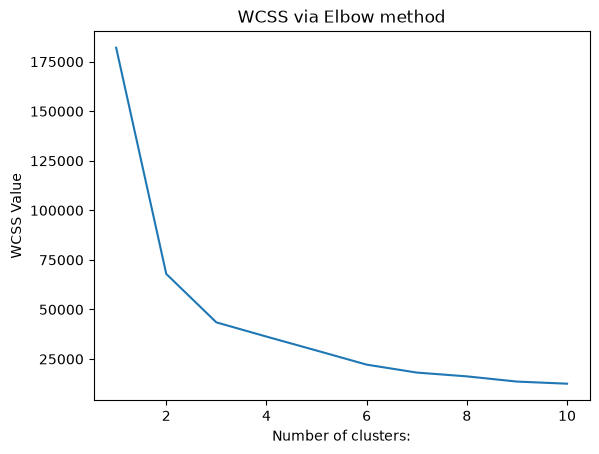

In [4]:
wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=21)
    model.fit(x)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS via Elbow method')
plt.xlabel('Number of clusters:')
plt.ylabel('WCSS Value')
plt.show()

## K-Means Clustering (k=4)

In [5]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42)
y_means = model.fit_predict(x)
print("y_means:\n", y_means)

y_means:
 [0 2 2 3 2 0 3 0 2 2 2 0 2 0 0 0 1 1 1 3 0 0 3 0 0 1 3 3 0 1 2 3 0 3 1 0 3
 1 2 2 0 2 2 0 2 1 0 0 2 2 0 0 1 2 0 0 2 0 1 3 3 2 1 3 0 2 0 2 2 3 2 0 0 3
 0 2 0 3 0 2 2 1 2 2 1 2 0 0 0 2 2 2 2 2 1 3 2 0 1 1 0 0 1 3 1 0 1 0 0 0 0
 0 2 2 2 2 0 0 3 0 1 2 2 3 2 1 2 1 0 0 2 0 2 2 1 0 2 1 2 2 2 2 0 3 2 1 0 3
 1 1 2 1 1 2 0 3 2 3 1 2 3 0 2 2 1 2 0 0 1 3 0 2 1 2 2 2 0 3 1 2 2 0 3 1 0
 0 1 0 0 1 3 0 2 2 0 3 2 0 1 0]


## Visualize the Clusters

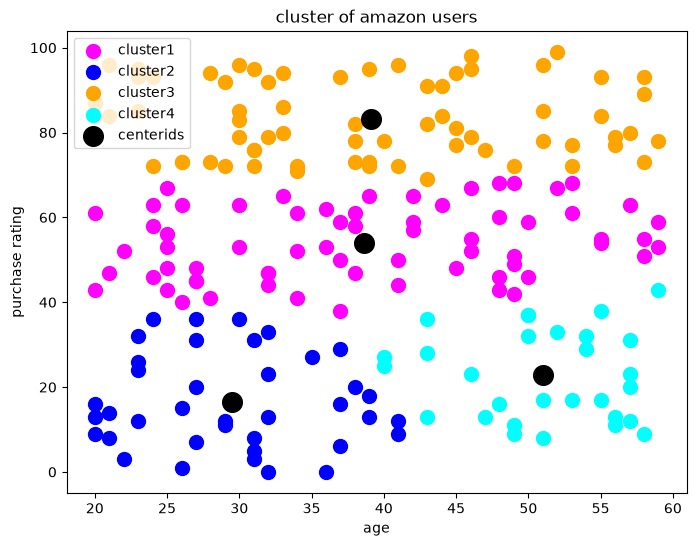

In [6]:
plt.figure(figsize=(8, 6))
plt.scatter(x[y_means==0, 0], x[y_means==0, 1], s=100, c='magenta', label='cluster1')
plt.scatter(x[y_means==1, 0], x[y_means==1, 1], s=100, c='blue', label='cluster2')
plt.scatter(x[y_means==2, 0], x[y_means==2, 1], s=100, c='orange', label='cluster3')
plt.scatter(x[y_means==3, 0], x[y_means==3, 1], s=100, c='cyan', label='cluster4')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], s=200, c='black', label='centerids')
plt.title('cluster of amazon users')
plt.xlabel('age')
plt.ylabel('purchase rating')
plt.legend()
plt.show()